In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- parameters ---
V_rest = -65.0   # mV, resting voltage
tau = 10.0       # ms, time constant (how fast it leaks back to rest)
R = 10.0         # membrane resistance (not used yet, I=0)
dt = 0.1         # ms, size of each time step

In [3]:
# --- initial condition: start away from rest, to watch it settle ---
V = -40.0        # mV

# --- time array: simulate 100 ms ---
t = np.arange(0, 100, dt)
V_trace = np.zeros(len(t))   # we'll store V at every time step here

I = 0.0  # no input current yet

for i, current_t in enumerate(t):
    V_trace[i] = V                          # record V BEFORE updating it
    dVdt = (-(V - V_rest) + R * I) / tau    # the leak equation
    V = V + dVdt * dt                       # nudge V forward by one small step


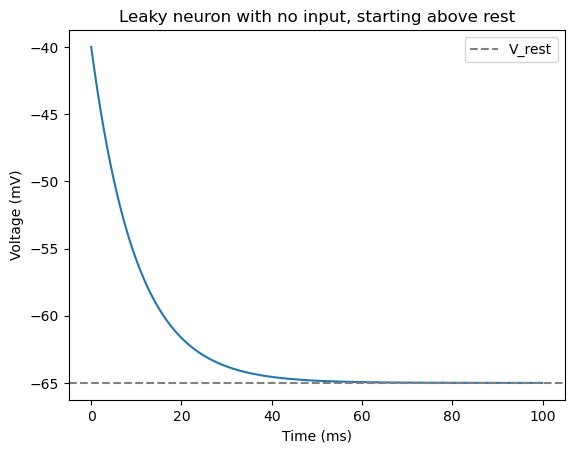

In [4]:
# --- plot ---
plt.plot(t, V_trace)
plt.axhline(V_rest, color='gray', linestyle='--', label='V_rest')
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Leaky neuron with no input, starting above rest")
plt.legend()
plt.show()

Comparing different tau values

This time we'll wrap the simulation in a function so we can easily run it with different tau values and compare.

In [5]:
def simulate(tau, V0=-40.0, T=100):
    t = np.arange(0, T, dt)
    V_trace = np.zeros(len(t))
    V = V0
    for i, current_t in enumerate(t):
        V_trace[i] = V
        dVdt = (-(V - V_rest) + R * I) / tau
        V = V + dVdt * dt
    return t, V_trace


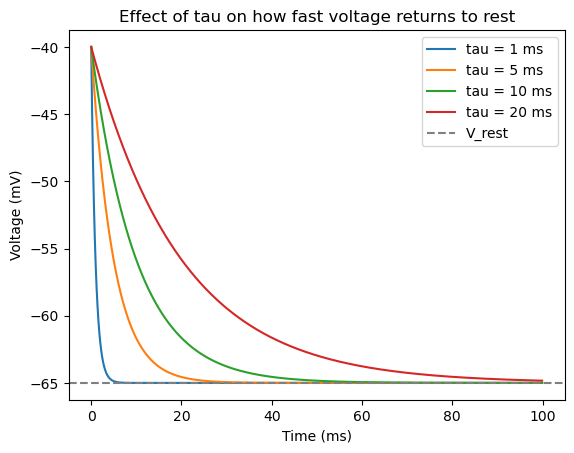

In [6]:
plt.figure()
for tau_val in [1, 5, 10, 20]:
    t, V_trace = simulate(tau_val)
    plt.plot(t, V_trace, label=f"tau = {tau_val} ms")

plt.axhline(V_rest, color='gray', linestyle='--', label='V_rest')
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Effect of tau on how fast voltage returns to rest")
plt.legend()
plt.show()

Now we bring the R * I term to life. Instead of I = 0, we'll inject a constant current and watch voltage rise and settle at a new steady-state level (instead of returning to V_rest).

In [8]:
def simulate_with_input(I, T=100, V0=-65.0):
    t = np.arange(0, T, dt)
    V_trace = np.zeros(len(t))
    V = V0
    for i, current_t in enumerate(t):
        V_trace[i] = V
        dVdt = (-(V - V_rest) + R * I) / tau
        V = V + dVdt * dt
    return t, V_trace


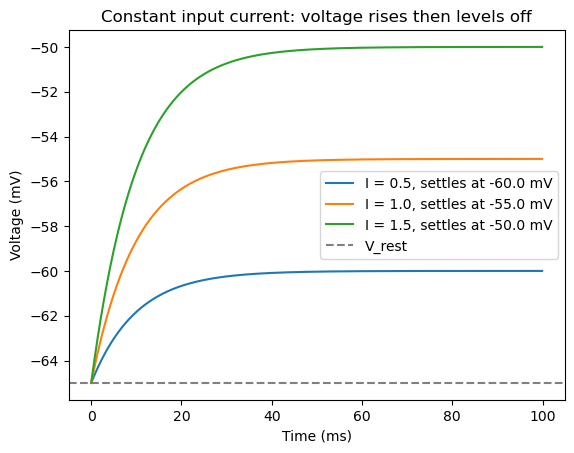

In [9]:
plt.figure()
for I_val in [0.5, 1.0, 1.5]:
    t, V_trace = simulate_with_input(I_val)
    steady_state = V_rest + R * I_val   # theoretical balance point
    plt.plot(t, V_trace, label=f"I = {I_val}, settles at {steady_state:.1f} mV")

plt.axhline(V_rest, color='gray', linestyle='--', label='V_rest')
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Constant input current: voltage rises then levels off")
plt.legend()
plt.show()

Adding threshold and reset (this is where spikes appear)

In [10]:
V_threshold = -50.0   # cross this and the neuron fires
V_reset = -65.0        # snap back to this after spiking
V_spike_peak = 40.0    # just a visual trick so the spike is visible on the plot

def simulate_spiking(I, T=100):
    t = np.arange(0, T, dt)
    V_trace = np.zeros(len(t))
    V = V_rest
    spike_times = []

    for i, current_t in enumerate(t):
        if V >= V_threshold:
            spike_times.append(current_t)
            V_trace[i] = V_spike_peak   # draw the spike tip
            V = V_reset                 # then reset
        else:
            V_trace[i] = V
            dVdt = (-(V - V_rest) + R * I) / tau
            V = V + dVdt * dt

    return t, V_trace, spike_times

I = 1.8  # steady-state would be V_rest + R*I = -47 mV, which is above threshold (-50 mV)
t, V_trace, spike_times = simulate_spiking(I)

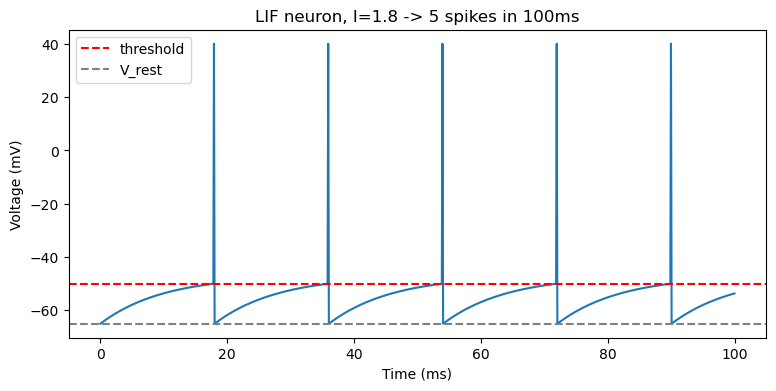

Spike times (ms): [np.float64(17.9), np.float64(35.9), np.float64(53.9), np.float64(71.9), np.float64(89.9)]


In [11]:
plt.figure(figsize=(9, 4))
plt.plot(t, V_trace)
plt.axhline(V_threshold, color='red', linestyle='--', label='threshold')
plt.axhline(V_rest, color='gray', linestyle='--', label='V_rest')
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title(f"LIF neuron, I={I} -> {len(spike_times)} spikes in {t[-1]:.0f}ms")
plt.legend()
plt.show()

print("Spike times (ms):", [round(s, 1) for s in spike_times])

We'll sweep I across a range of values, count how many spikes each one produces, and turn that into a firing rate in Hz.

In [12]:
def get_spike_count(I, T=200):
    t = np.arange(0, T, dt)
    V = V_rest
    spike_times = []
    for current_t in t:
        if V >= V_threshold:
            spike_times.append(current_t)
            V = V_reset
        else:
            dVdt = (-(V - V_rest) + R * I) / tau
            V = V + dVdt * dt
    return len(spike_times)

currents = np.arange(0, 3.05, 0.05)
T = 200  # ms, simulation duration for each current value
firing_rates = []

for I_val in currents:
    n_spikes = get_spike_count(I_val, T=T)
    rate_hz = n_spikes / (T / 1000.0)   # convert spike count over T ms into spikes/sec
    firing_rates.append(rate_hz)

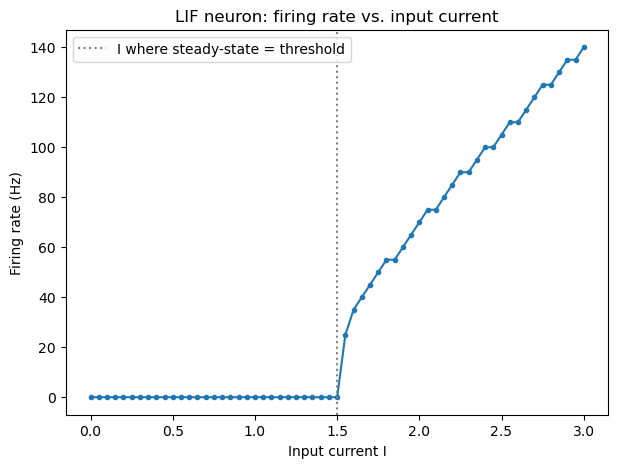

In [13]:
plt.figure(figsize=(7, 5))
plt.plot(currents, firing_rates, marker='o', markersize=3)
plt.axvline(1.5, color='gray', linestyle=':', label='I where steady-state = threshold')
plt.xlabel("Input current I")
plt.ylabel("Firing rate (Hz)")
plt.title("LIF neuron: firing rate vs. input current")
plt.legend()
plt.show()